# Qualitative Failure Case Analysis — Dataset002_Heart

This notebook provides interactive tools for inspecting nnU-Net **postprocessed** predictions on the left-atrium segmentation task.  
For each case you can:
- browse raw MRI slices,
- overlay True Positives / False Positives / False Negatives on the scan,
- read per-case voxel-level statistics alongside the Dice score from `summary.json`.

Predictions come from `crossval_results_folds_0_1_2_3_4/postprocessed/` (all 20 cases, all folds combined).  
**Only edit Cell 1** to switch between cases or viewing axes.

## Cell 1 — Imports & configuration

Set `CASE_ID` and `AXIS` here. All downstream paths are derived automatically from the location of this notebook.  
Predictions are loaded from the **postprocessed cross-validation results** (all folds combined).  
If your data lives in a non-standard location you can override `DATA_BASE` or `RESULTS_BASE` directly.

In [73]:
import os
import json
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path

# ── USER SETTINGS — edit only this block ──────────────────────
CASE_ID = "la_020"   # e.g. "la_003", "la_007", "la_016" …
AXIS    = "axial"    # "axial" | "coronal" | "sagittal"
# ──────────────────────────────────────────────────────────────

# Paths derived from notebook location — adjust only if layout changed
NOTEBOOK_DIR  = Path(os.getcwd()).resolve()          # .../Dataset002_Heart/analysis/
DATASET_DIR   = NOTEBOOK_DIR.parent                  # .../Dataset002_Heart/
RESULTS_BASE  = DATASET_DIR / "nnUNetTrainer_100epochs__nnUNetPlans__3d_fullres"
DATA_BASE     = DATASET_DIR.parent.parent.parent / "data" / "Task02_Heart"

# Postprocessed predictions (all folds combined)
POSTPROC_DIR = RESULTS_BASE / "crossval_results_folds_0_1_2_3_4" / "postprocessed"
SUMMARY_PATH = POSTPROC_DIR / "summary.json"
PRED_PATH    = POSTPROC_DIR / f"{CASE_ID}.nii.gz"
GT_PATH      = DATA_BASE / "labelsTr" / f"{CASE_ID}.nii.gz"

# Raw image: try _0000 suffix first (nnU-Net renamed), fall back to plain
_img_0000  = DATA_BASE / "imagesTr" / f"{CASE_ID}_0000.nii.gz"
_img_plain = DATA_BASE / "imagesTr" / f"{CASE_ID}.nii.gz"
IMG_PATH = _img_0000 if _img_0000.exists() else _img_plain

print("Resolved paths:")
for label, p in [("Image", IMG_PATH), ("GT", GT_PATH),
                 ("Prediction", PRED_PATH), ("Summary", SUMMARY_PATH)]:
    status = "OK" if p.exists() else "NOT FOUND"
    print(f"  {label:<12}: {p}  [{status}]")

Resolved paths:
  Image       : C:\Users\Walid\Documents\GitHub\Project\data\Task02_Heart\imagesTr\la_020.nii.gz  [OK]
  GT          : C:\Users\Walid\Documents\GitHub\Project\data\Task02_Heart\labelsTr\la_020.nii.gz  [OK]
  Prediction  : C:\Users\Walid\Documents\GitHub\Project\runpods\nnUNet_results\Dataset002_Heart\nnUNetTrainer_100epochs__nnUNetPlans__3d_fullres\crossval_results_folds_0_1_2_3_4\postprocessed\la_020.nii.gz  [OK]
  Summary     : C:\Users\Walid\Documents\GitHub\Project\runpods\nnUNet_results\Dataset002_Heart\nnUNetTrainer_100epochs__nnUNetPlans__3d_fullres\crossval_results_folds_0_1_2_3_4\postprocessed\summary.json  [OK]


## Cell 2 — Load data

Loads the three NIfTI volumes (raw MRI, ground-truth label, postprocessed prediction) via `nibabel` and reads the per-case Dice score from the postprocessed `summary.json`.  
Prints shapes and voxel spacing to verify everything loaded correctly.

In [74]:
# ── Load NIfTI volumes ────────────────────────────────────────
img_nib  = nib.load(IMG_PATH)
gt_nib   = nib.load(GT_PATH)
pred_nib = nib.load(PRED_PATH)

img_data  = img_nib.get_fdata()
gt_data   = gt_nib.get_fdata().astype(np.uint8)
pred_data = pred_nib.get_fdata().astype(np.uint8)

spacing = img_nib.header.get_zooms()[:3]

print(f"Image shape   : {img_data.shape}")
print(f"GT shape      : {gt_data.shape}")
print(f"Pred shape    : {pred_data.shape}")
print(f"Voxel spacing : {tuple(round(float(s), 3) for s in spacing)} mm  (x, y, z)")

# ── Pull Dice from postprocessed summary.json ─────────────────
with open(SUMMARY_PATH) as f:
    summary = json.load(f)

dice_score = float("nan")
for case in summary["metric_per_case"]:
    if Path(case["prediction_file"]).name == f"{CASE_ID}.nii.gz":
        dice_score = case["metrics"]["1"]["Dice"]
        break

if not np.isnan(dice_score):
    print(f"\nDice (postprocessed, {CASE_ID}) : {dice_score:.4f}")
else:
    print(f"\nWARNING: {CASE_ID} not found in {SUMMARY_PATH}")

Image shape   : (320, 320, 110)
GT shape      : (320, 320, 110)
Pred shape    : (320, 320, 110)
Voxel spacing : (1.25, 1.25, 1.37) mm  (x, y, z)

Dice (postprocessed, la_020) : 0.8961


## Cell 2b — Diagnostic image : résolution, qualité, couverture

Cette cellule répond à trois questions avant même d'ouvrir un slice :

| Hypothèse | Indicateur clé |
|-----------|----------------|
| **Petit atrium** | Volume GT < 50 mL, boîte englobante réduite |
| **Mauvaise qualité d'image** | SNR faible, contraste Michelson faible |
| **Manque de coupes** | Nombre de coupes axiales contenant du label < 10 |

Tous les seuils sont commentés dans le code pour justifier le choix.

In [75]:
# ═══════════════════════════════════════════════════════════════════════
# CELLULE DE DIAGNOSTIC D'IMAGE
# Objectif : identifier AVANT d'ouvrir un slice les causes probables
#            d'un Dice faible.  Trois hypothèses à tester :
#   (A) Petit atrium gauche  → volume GT faible, petite boîte englobante
#   (B) Mauvaise qualité d'image → SNR faible, contraste Michelson faible
#   (C) Couverture insuffisante  → peu de coupes axiales avec du label GT
# ═══════════════════════════════════════════════════════════════════════

import numpy as np  # déjà importé en Cell 1 ; rappel explicite pour lisibilité

# ─── 1. PARAMÈTRES D'ACQUISITION ─────────────────────────────────────────────
# get_zooms() renvoie l'espacement voxel depuis l'en-tête NIfTI.
# sx, sy = résolution in-plane (plan axial)
# sz     = épaisseur de coupe
# Un sz élevé (> 3 mm) signifie que l'atrium est couviert sur peu de coupes,
# ce qui dégrade la précision sur les bords supérieur et inférieur de la cible.
sx, sy, sz    = [float(s) for s in spacing]
voxel_vol_mm3 = sx * sy * sz           # volume d'un voxel en mm³

Hx, Hy, Hz = img_data.shape
fov_mm = (Hx * sx, Hy * sy, Hz * sz)  # champ de vue total en mm

print("━" * 58)
print("  1. PARAMÈTRES D'ACQUISITION")
print("━" * 58)
print(f"  Résolution in-plane   : {sx:.3f} × {sy:.3f} mm")
print(f"  Épaisseur de coupe    : {sz:.3f} mm")

# Rapport anisotropie z / résolution moyenne in-plane :
# > 2 = acquisition fortement anisotrope → l'atrium est sous-résolu dans l'axe z,
# les bords sup/inf sont flous et difficiles à délimiter même pour un humain.
ratio_aniso = sz / ((sx + sy) / 2)
aniso_flag  = "⚠ ANISOTROPE (z/xy > 2)" if ratio_aniso > 2.0 else "✓ quasi-isotrope"
print(f"  Rapport z / (x+y)/2   : {ratio_aniso:.2f}  → {aniso_flag}")
print(f"  Dimensions (voxels)   : {Hx} × {Hy} × {Hz}")
print(f"  Champ de vue (mm)     : {fov_mm[0]:.1f} × {fov_mm[1]:.1f} × {fov_mm[2]:.1f}")
print(f"  Volume voxel          : {voxel_vol_mm3:.4f} mm³")

# ─── 2. MORPHOLOGIE DE L'ATRIUM GAUCHE (GT) ──────────────────────────────────
# On quantifie la TAILLE RÉELLE de l'atrium depuis le masque Ground Truth.
#
# Références cliniques adulte sain (IRM cardiaque) :
#   volume atrium gauche (LAV) normal : 50–110 mL
#   LAV < 50 mL → petit atrium : même 1 mm d'erreur = gros % de volume,
#                 ce qui se traduit par un Dice instable même pour une bonne
#                 segmentation qualitative.
#   LAV > 130 mL → atrium dilaté (pathologie connue comme FA ou insuffisance
#                  mitrale), structure déformée → contours plus difficiles.
print()
print("━" * 58)
print("  2. MORPHOLOGIE DE L'ATRIUM GAUCHE (GT)")
print("━" * 58)

gt_voxels  = int(gt_data.sum())
gt_vol_mm3 = gt_voxels * voxel_vol_mm3
gt_vol_mL  = gt_vol_mm3 / 1000.0

print(f"  Voxels GT (label=1)   : {gt_voxels:,}")
print(f"  Volume GT             : {gt_vol_mm3:,.0f} mm³  ({gt_vol_mL:.1f} mL)")

if gt_vol_mL < 50:
    size_flag = "⚠ PETIT ATRIUM (< 50 mL) — Dice instable sur petites cibles"
elif gt_vol_mL > 130:
    size_flag = "⚠ ATRIUM DILATÉ (> 130 mL) — morphologie atypique"
else:
    size_flag = "✓ volume normal (50–130 mL)"
print(f"  Diagnostic volume     : {size_flag}")

# Boîte englobante 3D → extension spatiale de l'atrium dans les 3 axes.
# Petite dimension en z = atrium "plat" sur peu de coupes.
# Petite dimension in-plane = atrium restreint latéralement.
coords_gt   = np.argwhere(gt_data == 1)
bb_min      = coords_gt.min(axis=0)   # (x_min, y_min, z_min)
bb_max      = coords_gt.max(axis=0)   # (x_max, y_max, z_max)
bb_size_vox = bb_max - bb_min + 1
bb_size_mm  = bb_size_vox * np.array([sx, sy, sz])
print(f"  Boîte englobante      : {bb_size_vox[0]}×{bb_size_vox[1]}×{bb_size_vox[2]} vox")
print(f"  Boîte englobante (mm) : {bb_size_mm[0]:.1f}×{bb_size_mm[1]:.1f}×{bb_size_mm[2]:.1f} mm")

# ─── 3. COUVERTURE EN COUPES AXIALES ─────────────────────────────────────────
# On compte les coupes qui contiennent AU MOINS 1 voxel GT.
# nnU-Net est un réseau 3D : si l'atrium n'occupe que quelques coupes,
# le réseau a peu de contexte volumique pour apprendre ses contours.
# Seuils empiriques (issus de la littérature nnU-Net) :
#   < 10 coupes → couverture très faible, risque de faux-positifs isolés
#   10–20 coupes → limit acceptable mais attention aux cas extrêmes
#   ≥ 20 coupes → contexte 3D confortable
print()
print("━" * 58)
print("  3. COUVERTURE EN COUPES AXIALES")
print("━" * 58)

slices_with_label = [z for z in range(Hz) if gt_data[:, :, z].sum() > 0]
n_with        = len(slices_with_label)
coverage_pct  = 100 * n_with / Hz

print(f"  Coupes totales        : {Hz}")
print(f"  Coupes avec atrium    : {n_with}  (indices {slices_with_label[0]}–{slices_with_label[-1]})")
print(f"  Couverture            : {coverage_pct:.1f}% du volume total")

if n_with < 10:
    cov_flag = "⚠ TROP PEU DE COUPES (< 10) — contexte 3D insuffisant"
elif n_with < 20:
    cov_flag = "~ couverture limite (10–20 coupes)"
else:
    cov_flag = "✓ couverture suffisante (≥ 20 coupes)"
print(f"  Diagnostic coupes     : {cov_flag}")

# Aire de l'atrium sur la coupe axiale médiane (proxy de la section 2D max).
# Une petite aire = structure 2D difficile à délimiter au bord du FOV.
mid_z          = slices_with_label[len(slices_with_label) // 2]
mid_area_vox   = int(gt_data[:, :, mid_z].sum())
mid_area_mm2   = mid_area_vox * sx * sy
print(f"  Aire max (coupe {mid_z:3d})  : {mid_area_vox:,} vox  ({mid_area_mm2:.0f} mm²)")

# ─── 4. QUALITÉ D'IMAGE (proxies sans fantôme) ────────────────────────────────
# Sans fantôme de calibration on estime la qualité via deux proxies :
#
#  a) SNR (Signal-to-Noise Ratio)
#     signal = intensité médiane dans la région GT (atrium, sang)
#     bruit  = std des pixels dans les coins du volume
#     → Les coins contiennent généralement de l'air ou du bruit de fond,
#       sans signal anatomique : c'est l'estimation de bruit la plus simple
#       et la plus reproductible sans annotation supplémentaire.
#     Seuils orientatifs IRM cardiaque : SNR < 5 = trop bruité,
#       5–15 = acceptable, > 15 = bonne qualité.
#
#  b) Contraste de Michelson atrium / tissu voisin
#     = (I_atrium - I_voisin) / (I_atrium + I_voisin)
#     tissu voisin = voxels hors GT dans la même étendue axiale que l'atrium.
#     On utilise cet estimateur car il est normalisé et invariant au décalage DC.
#     |contraste| < 0.05 → atrium quasi invisible → erreurs de segmentation
#     presque inévitables même pour un réseau bien entraîné.
print()
print("━" * 58)
print("  4. QUALITÉ D'IMAGE (proxies)")
print("━" * 58)

# Estimation du bruit : std dans les coins du volume (~ 5% des bords)
margin = max(10, Hx // 20)
bg = np.concatenate([
    img_data[:margin,   :margin,  :].ravel(),
    img_data[-margin:, -margin:,  :].ravel(),
    img_data[:margin,  -margin:,  :].ravel(),
    img_data[-margin:,  :margin,  :].ravel(),
])
noise_std  = float(np.std(bg))

# Signal dans l'atrium (pixels GT = 1)
atrium_px  = img_data[gt_data == 1]
sig_median = float(np.median(atrium_px))
sig_p5     = float(np.percentile(atrium_px,  5))
sig_p95    = float(np.percentile(atrium_px, 95))
snr        = sig_median / (noise_std + 1e-8)

print(f"  Signal médiane (GT)   : {sig_median:.1f}")
print(f"  Signal P5–P95         : {sig_p5:.1f} – {sig_p95:.1f}")
print(f"  Bruit estimé (std)    : {noise_std:.1f}")
print(f"  SNR estimé            : {snr:.1f}")

if snr < 5:
    snr_flag = "⚠ SNR FAIBLE (< 5) — image très bruitée"
elif snr < 15:
    snr_flag = "~ SNR moyen (5–15)"
else:
    snr_flag = "✓ SNR correct (> 15)"
print(f"  Diagnostic SNR        : {snr_flag}")

# Contraste Michelson : tissu voisin = hors GT dans la même plage axiale
z0, z1   = int(bb_min[2]), int(bb_max[2])
roi_mask = np.zeros_like(gt_data, dtype=bool)
roi_mask[:, :, z0:z1+1] = True
adj_px   = img_data[(roi_mask) & (gt_data == 0)]
if len(adj_px) > 100:
    adj_median = float(np.median(adj_px))
    contrast   = (sig_median - adj_median) / (abs(sig_median) + abs(adj_median) + 1e-8)
    print(f"  Signal tissu voisin   : {adj_median:.1f}")
    print(f"  Contraste Michelson   : {contrast:.3f}")
    if abs(contrast) < 0.05:
        c_flag = "⚠ CONTRASTE TRÈS FAIBLE — atrium difficile à délimiter"
    elif abs(contrast) < 0.15:
        c_flag = "~ contraste limité"
    else:
        c_flag = "✓ contraste suffisant"
    print(f"  Diagnostic contraste  : {c_flag}")
else:
    contrast, c_flag = float('nan'), "(données insuffisantes)"

# ─── 5. RÉSUMÉ DIAGNOSTIQUE ──────────────────────────────────────────────────
# Récapitulatif une ligne par hypothèse pour guider l'analyse visuelle.
# Lire ce résumé avant de scroller les slices permet de savoir où chercher.
print()
print("═" * 58)
print("  RÉSUMÉ DIAGNOSTIQUE")
print("═" * 58)
print(f"  Dice (postprocessed)  : {dice_score:.4f}")
print(f"  Volume atrium (GT)    : {gt_vol_mL:.1f} mL  → {size_flag.split('—')[0].strip()}")
print(f"  Coupes avec atrium    : {n_with}  → {cov_flag.split('—')[0].strip()}")
print(f"  SNR estimé            : {snr:.1f}  → {snr_flag.split('—')[0].strip()}")
print(f"  Anisotropie z/xy      : {ratio_aniso:.2f}  → {aniso_flag}")
print("═" * 58)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. PARAMÈTRES D'ACQUISITION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Résolution in-plane   : 1.250 × 1.250 mm
  Épaisseur de coupe    : 1.370 mm
  Rapport z / (x+y)/2   : 1.10  → ✓ quasi-isotrope
  Dimensions (voxels)   : 320 × 320 × 110
  Champ de vue (mm)     : 400.0 × 400.0 × 150.7
  Volume voxel          : 2.1406 mm³

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  2. MORPHOLOGIE DE L'ATRIUM GAUCHE (GT)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Voxels GT (label=1)   : 32,040
  Volume GT             : 68,586 mm³  (68.6 mL)
  Diagnostic volume     : ✓ volume normal (50–130 mL)
  Boîte englobante      : 38×44×70 vox
  Boîte englobante (mm) : 47.5×55.0×95.9 mm

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  3. COUVERTURE EN COUPES AXIALES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Coupes totales        : 110
  Coupes avec atrium    : 70  (indi

## Cell 3 — Raw scan viewer

An interactive slider that steps through slices of the raw MRI volume (no overlay).  
Use this to get oriented: find anatomical landmarks, identify where the atrium sits, and note slice indices you want to inspect more closely in the overlay viewer below.

`AXIS` controls the viewing plane: `"axial"` (z-axis), `"coronal"` (y-axis), `"sagittal"` (x-axis).

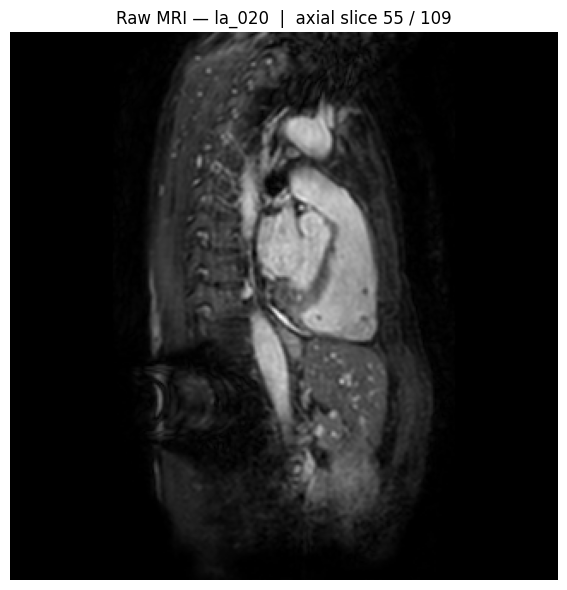

interactive(children=(IntSlider(value=55, continuous_update=False, description='Slice:', layout=Layout(width='…

In [76]:
# ── Axis helpers ──────────────────────────────────────────────
def _n_slices(vol, axis):
    return {"axial": vol.shape[2], "coronal": vol.shape[1], "sagittal": vol.shape[0]}[axis]

def _get_slice(vol, idx, axis):
    """Return a 2-D array; transpose so origin='lower' gives anatomical orientation."""
    if axis == "axial":
        return vol[:, :, idx].T
    elif axis == "coronal":
        return vol[:, idx, :].T
    elif axis == "sagittal":
        return vol[idx, :, :].T
    raise ValueError(f"Unknown axis '{axis}'. Use 'axial', 'coronal', or 'sagittal'.")

# ── Interactive raw viewer ────────────────────────────────────
N_SLICES = _n_slices(img_data, AXIS)

def _show_raw(idx):
    sl = _get_slice(img_data, idx, AXIS)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(sl, cmap="gray", origin="lower", aspect="equal")
    ax.set_title(f"Raw MRI — {CASE_ID}  |  {AXIS} slice {idx} / {N_SLICES - 1}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

raw_slider = widgets.IntSlider(
    value=N_SLICES // 2, min=0, max=N_SLICES - 1, step=1,
    description="Slice:", continuous_update=False,
    layout=widgets.Layout(width="520px")
)
widgets.interact(_show_raw, idx=raw_slider);

## Cell 4 — Overlay viewer: TP / FP / FN

Renders the same slice but with a semi-transparent colour overlay that codes prediction errors:

| Colour | Meaning | Condition |
|--------|---------|---|
| **Green** | True Positive  | pred = 1 **and** gt = 1 |
| **Red**   | False Positive | pred = 1 **and** gt = 0 |
| **Blue**  | False Negative | pred = 0 **and** gt = 1 |

The title shows the Dice score pulled from the postprocessed `summary.json`.  
The overlay is built as an RGBA array and composited directly onto the grayscale background via a second `imshow` call.

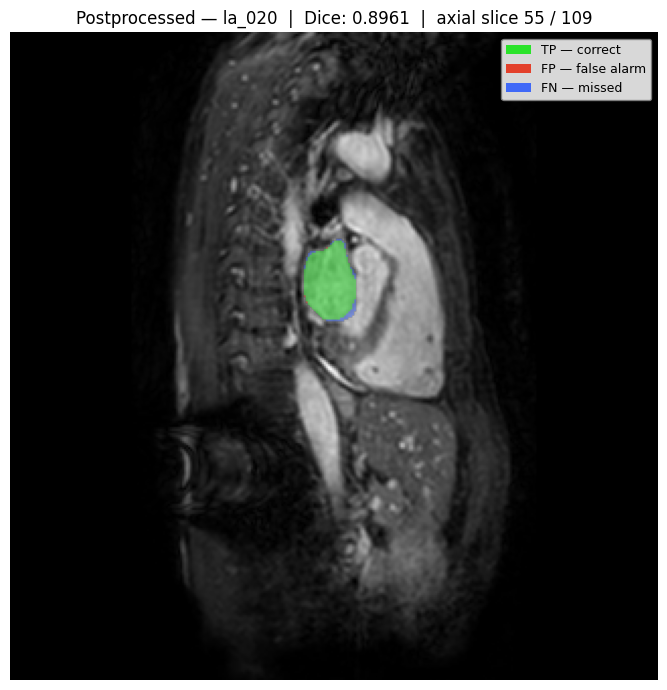

interactive(children=(IntSlider(value=55, continuous_update=False, description='Slice:', layout=Layout(width='…

66

In [77]:
# ── Pre-compute error masks (done once) ───────────────────────
TP_mask = (pred_data == 1) & (gt_data == 1)
FP_mask = (pred_data == 1) & (gt_data == 0)
FN_mask = (pred_data == 0) & (gt_data == 1)

ALPHA = 0.4   # overlay transparency

# ── Interactive overlay viewer ────────────────────────────────
def _show_overlay(idx):
    sl_img = _get_slice(img_data,             idx, AXIS)
    sl_tp  = _get_slice(TP_mask.astype("u1"), idx, AXIS)
    sl_fp  = _get_slice(FP_mask.astype("u1"), idx, AXIS)
    sl_fn  = _get_slice(FN_mask.astype("u1"), idx, AXIS)

    # Normalize MRI to [0, 1]
    vmin, vmax = sl_img.min(), sl_img.max()
    sl_norm = (sl_img - vmin) / (vmax - vmin + 1e-8)

    H, W = sl_norm.shape

    # Build RGBA overlay array
    overlay = np.zeros((H, W, 4), dtype=np.float32)
    overlay[sl_tp == 1] = [0.0, 0.9, 0.0, ALPHA]   # green — TP
    overlay[sl_fp == 1] = [0.9, 0.1, 0.0, ALPHA]   # red   — FP
    overlay[sl_fn == 1] = [0.1, 0.3, 1.0, ALPHA]   # blue  — FN

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(sl_norm, cmap="gray", origin="lower", aspect="equal")
    ax.imshow(overlay,             origin="lower", aspect="equal")

    legend_patches = [
        mpatches.Patch(facecolor=(0.0, 0.9, 0.0), alpha=0.8, label="TP — correct"),
        mpatches.Patch(facecolor=(0.9, 0.1, 0.0), alpha=0.8, label="FP — false alarm"),
        mpatches.Patch(facecolor=(0.1, 0.3, 1.0), alpha=0.8, label="FN — missed"),
    ]
    ax.legend(handles=legend_patches, loc="upper right", fontsize=9,
              framealpha=0.85, edgecolor="gray")
    ax.set_title(
        f"Postprocessed — {CASE_ID}  |  Dice: {dice_score:.4f}  |  {AXIS} slice {idx} / {N_SLICES - 1}"
    )
    ax.axis("off")
    plt.tight_layout()
    plt.show()

overlay_slider = widgets.IntSlider(
    value=N_SLICES // 2, min=0, max=N_SLICES - 1, step=1,
    description="Slice:", continuous_update=False,
    layout=widgets.Layout(width="520px")
)
widgets.interact(_show_overlay, idx=overlay_slider);
66


## Cell 5 — Per-case statistics

Aggregates voxel-level counts across the full 3-D volume (not just the current slice) and prints a summary table of TP, FP, FN, Precision, Recall, and Dice.  
A bar chart gives an immediate visual sense of the error balance: a FP-heavy case suggests over-segmentation; FN-heavy suggests under-segmentation.

Case: la_020   (postprocessed)
TP voxels            26,392
FP voxels               472
FN voxels             5,648
------------------------------
Precision            0.9824
Recall               0.8237
Dice (calc)          0.8961
Dice (json)          0.8961


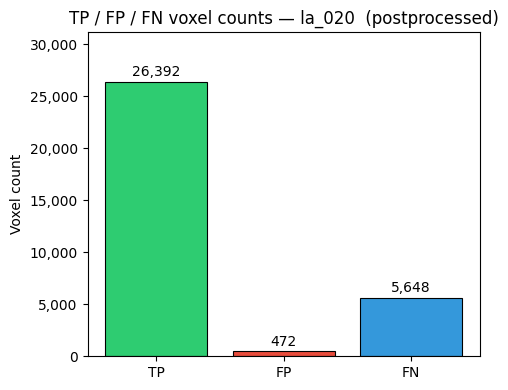

In [78]:
# ── Aggregate 3-D counts ──────────────────────────────────────
TP = int(TP_mask.sum())
FP = int(FP_mask.sum())
FN = int(FN_mask.sum())

precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
dice_calc = 2 * TP / (2 * TP + FP + FN) if (2 * TP + FP + FN) > 0 else 0.0

# ── Print table ───────────────────────────────────────────────
print(f"Case: {CASE_ID}   (postprocessed)")
print("=" * 30)
print(f"{'TP voxels':<14} {TP:>12,}")
print(f"{'FP voxels':<14} {FP:>12,}")
print(f"{'FN voxels':<14} {FN:>12,}")
print("-" * 30)
print(f"{'Precision':<14} {precision:>12.4f}")
print(f"{'Recall':<14} {recall:>12.4f}")
print(f"{'Dice (calc)':<14} {dice_calc:>12.4f}")
print(f"{'Dice (json)':<14} {dice_score:>12.4f}")

# ── Bar chart ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
colors = ["#2ecc71", "#e74c3c", "#3498db"]
bars = ax.bar(["TP", "FP", "FN"], [TP, FP, FN],
              color=colors, edgecolor="black", linewidth=0.8)

y_max = max(TP, FP, FN)
for bar, val in zip(bars, [TP, FP, FN]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + y_max * 0.01,
        f"{val:,}", ha="center", va="bottom", fontsize=10
    )

ax.set_ylabel("Voxel count")
ax.set_title(f"TP / FP / FN voxel counts — {CASE_ID}  (postprocessed)")
ax.set_ylim(0, y_max * 1.18)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

## Cell 6 — 3D surface render

Extrait les surfaces 3D de chaque masque (TP, FP, FN) par **marching cubes** (`skimage`) et les affiche dans un seul rendu 3D.  
Contrairement aux vues 2D, ce rendu montre la **totalité du volume** d'un seul coup et est indépendant de l'axe `AXIS`.

| Couleur | Signification |
|---------|---------------|
| **Vert** | True Positive — bien segmenté |
| **Rouge** | False Positive — fausse alarme |
| **Bleu** | False Negative — manqué |

`DOWNSAMPLE` réduit la résolution pour accélérer le rendu (1 = résolution complète, 2 = moitié, etc.).

In [79]:
import importlib, subprocess, sys
if importlib.util.find_spec("plotly") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "plotly"], check=True)

import plotly.graph_objects as go
from IPython.display import HTML, display

traces = []
for mask, color, label in [
    (TP_mask, "green", "TP — correct"),
    (FP_mask, "red",   "FP — false alarm"),
    (FN_mask, "blue",  "FN — missed"),
]:
    coords = np.argwhere(mask)
    if len(coords) == 0:
        continue
    traces.append(go.Scatter3d(
        x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
        mode="markers",
        marker=dict(size=1.5, color=color, opacity=0.5),
        name=label,
    ))

fig = go.Figure(data=traces)
fig.update_layout(
    title=f"3D Segmentation — {CASE_ID}  |  Dice: {dice_score:.4f}",
    scene=dict(
        xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
        aspectmode="data",
    ),
    legend=dict(itemsizing="constant"),
    margin=dict(l=0, r=0, t=40, b=0),
    height=700,
)
display(HTML(fig.to_html(full_html=False, include_plotlyjs="cdn")))